In [1]:
import sys
sys.path.append('../src')

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

In [3]:
time = 200
d_mu = 100
d_sigma = 25
demand = np.maximum(np.random.normal(d_mu, d_sigma, time).round(0).astype(int), 0)

In [6]:
L, L_sigma = 4, 1

In [7]:
R, alpha = 1, 0.95
z = norm.ppf(alpha)
x_std = np.sqrt((L + R) * d_sigma**2 + L_sigma**2 * d_mu**2)
Ss = np.round(x_std * z).astype(int)
Cs = 0.5 * d_mu * R
Is = d_mu * L
S = Ss + 2 * Cs + Is

In [8]:
hand = np.zeros(time, dtype=int)
transit = np.zeros((time, L + 5 * L_sigma + 1), dtype=int)

In [9]:
hand[0] = S - demand[0]
transit[0, L] = demand[0]

In [10]:
stockout_period = np.full(time, False, dtype=bool)
stockout_cycle = []

In [15]:
for t in range(1, time):
    if transit[t - 1, 0] > 0:
        stockout_cycle.append(stockout_period[t - 1])
    hand[t] = hand[t - 1] - demand[t] + transit[t - 1, 0]
    stockout_period[t] = hand[t] < 0
    # hand[t] = max(hand[t], 0)  # Uncomment to prevent negative inventory: lost sales rather than backorders
    transit[t, :-1] = transit[t - 1, 1:]
    if 0 == t % R:
        actual_L = int(round(max(np.random.normal(L, L_sigma), 0), 0))
        try:
            max_L = int(max(np.argwhere(transit[t] > 0)))
        except:
            max_L = 0
        actual_L = max(actual_L, max_L)
        net = hand[t] + transit[t].sum()
        transit[t, actual_L] = S - net


/tmp/ipykernel_224107/2583106494.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_L = int(max(np.argwhere(transit[t] > 0)))


In [16]:
df = pd.DataFrame({
    "demand": demand,
    "on-hand": hand,
    "in-transit": list(transit),
})
df = df.iloc[R + L:, :]
df.head()

,demand,on-hand,in-transit
5,119,109,"[81, 0, 218, 161, 0, 119, 0, 0, 0, 0]"
6,118,72,"[0, 218, 161, 0, 118, 0, 0, 0, 0, 0]"
7,84,-12,"[218, 161, 0, 118, 0, 203, 0, 0, 0, 0]"
8,122,84,"[161, 0, 118, 0, 203, 122, 0, 0, 0, 0]"
9,83,162,"[0, 118, 0, 203, 122, 0, 83, 0, 0, 0]"


<Axes: title={'center': 'Inventory policy (1, 688.0)'}>

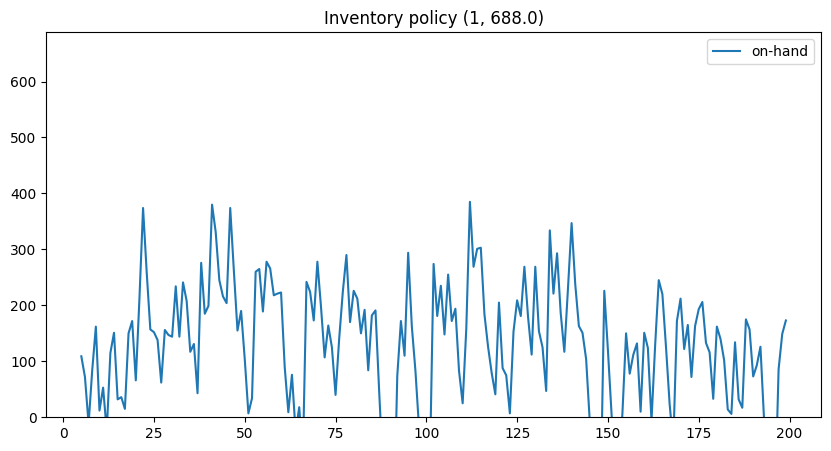

In [17]:
df["on-hand"].plot(title=f"Inventory policy ({R}, {S})", figsize=(10, 5), ylim=(0, S), legend=True)

In [18]:
print("Alpha:", alpha * 100, "%")
SL_alpha = 1 - sum(stockout_cycle) / len(stockout_cycle)
print("Service level:", SL_alpha * 100, "%")
SL_period = 1 - sum(stockout_period) / len(stockout_period)
print("Service level (periods):", SL_period * 100, "%")

Alpha: 95.0 %
Service level: 87.5 %
Service level (periods): 88.0 %
